<h1>Micro Project Title<br>
AIoT Healthcare Monitoring System with Advanced Anomaly Detection
</h1>
<h2>Submitted By: <br>
Manish Kumar Tiwari, <br>MAS-Data Science,2025, MBUST</h2>
<h2>Submitted To: <br>
Asst.Prof. Dr. Rituraj Lamsal,<br>Madan Bhandari University of Science and Technology (MBUST)
</h2>

In [1]:
%pip install numpy matplotlib scipy pandas seaborn scikit-learn statsmodels 

Active code page: 1252
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)


## Stage 1: Synthetic IoT Health Data Simulation

In [3]:

patients = range(1, 6)
time_index = pd.date_range("2024-01-01", periods=1440, freq='min')

records = []
for pid in patients:
    t = np.linspace(0, 2*np.pi, len(time_index))
    
    hr = 75 + 10*np.sin(t) + np.random.normal(0, 2, len(time_index))
    spo2 = 97 + 0.5*np.sin(t*2) + np.random.normal(0, 0.2, len(time_index))
    temp = 37 + 0.2*np.sin(t*3) + np.random.normal(0, 0.1, len(time_index))
    
    for _ in range(5):
        idx = np.random.randint(50, len(time_index)-5)
        hr[idx:idx+5] += np.random.choice([30, -25])
        spo2[idx:idx+5] -= np.random.choice([5, 10])
        temp[idx:idx+5] += np.random.choice([0.5, 1.0])
    
    hr[np.random.randint(len(time_index))] = 200
    spo2[np.random.randint(len(time_index))] = 50
    temp[np.random.randint(len(time_index))] = 40
    
    missing = np.random.choice(len(time_index), size=10, replace=False)
    hr[missing] = np.nan
    spo2[missing] = np.nan
    temp[missing] = np.nan
    
    df = pd.DataFrame({
        "timestamp": time_index,
        "patient_id": pid,
        "heart_rate": hr,
        "spo2": spo2,
        "temperature": temp
    })
    records.append(df)

data = pd.concat(records, ignore_index=True)

data["is_anomaly"] = 0
data.loc[(data.heart_rate > 150) | (data.heart_rate < 30), "is_anomaly"] = 1
data.loc[data.spo2 < 88, "is_anomaly"] = 1
data.loc[(data.temperature > 39) | (data.temperature < 35), "is_anomaly"] = 1
data.loc[data[["heart_rate","spo2","temperature"]].isnull().any(axis=1), "is_anomaly"] = 1

print(data)
#data.head()


               timestamp  patient_id  heart_rate       spo2  temperature  \
0    2024-01-01 00:00:00           1   75.993428  97.132576    36.776177   
1    2024-01-01 00:01:00           1   74.767135  97.239061    36.790550   
2    2024-01-01 00:02:00           1   76.382703  97.044937    36.944553   
3    2024-01-01 00:03:00           1   78.177047  96.753731    37.053626   
4    2024-01-01 00:04:00           1   74.706339  97.097399    36.735724   
...                  ...         ...         ...        ...          ...   
7195 2024-01-01 23:55:00           5   76.014435  97.094922    36.944443   
7196 2024-01-01 23:56:00           5   76.874290  96.686995    36.892327   
7197 2024-01-01 23:57:00           5   71.624583  96.704025    37.054650   
7198 2024-01-01 23:58:00           5   72.968171  97.092169    36.948492   
7199 2024-01-01 23:59:00           5   77.368313  96.932773    37.071841   

      is_anomaly  
0              0  
1              0  
2              0  
3          

In [4]:
print(data.shape)
print(data.is_anomaly.value_counts())
print(data.info())

(7200, 6)
is_anomaly
0    7062
1     138
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    7200 non-null   datetime64[ns]
 1   patient_id   7200 non-null   int64         
 2   heart_rate   7150 non-null   float64       
 3   spo2         7150 non-null   float64       
 4   temperature  7150 non-null   float64       
 5   is_anomaly   7200 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 337.6 KB
None


In [5]:
from pathlib import Path

# Save Stage 1 synthetic dataset to CSV in the notebook folder
output_file = Path.cwd() / "stage1_synthetic_health_data.csv"
data.to_csv(output_file, index=False)

print(f"CSV saved successfully: {output_file}")
print(f"Total rows exported: {len(data)}")

CSV saved successfully: c:\Users\HP\OneDrive\Desktop\MBUST\Ritu Raj sir\Assignment\stage1_synthetic_health_data.csv
Total rows exported: 7200


## Stage 2: Data Cleaning

In [6]:

cleaned = data.copy()

cleaned[['heart_rate','spo2','temperature']] = (
    cleaned.groupby("patient_id")[["heart_rate","spo2","temperature"]]
           .transform(lambda x: x.interpolate().ffill().bfill())
)

cleaned['heart_rate'] = cleaned['heart_rate'].clip(30, 150)
cleaned['spo2'] = cleaned['spo2'].clip(88, 100)
cleaned['temperature'] = cleaned['temperature'].clip(35, 39)

cleaned = cleaned.sort_values(['patient_id','timestamp'])

for col in ['heart_rate','spo2','temperature']:
    cleaned[f'{col}_diff'] = cleaned.groupby('patient_id')[col].diff().fillna(0)

cleaned.head()
#print(cleaned)


,timestamp,patient_id,heart_rate,spo2,temperature,is_anomaly,heart_rate_diff,spo2_diff,temperature_diff
0,2024-01-01 00:00:00,1,75.993428,97.132576,36.776177,0,0.000000,0.000000,0.000000
1,2024-01-01 00:01:00,1,74.767135,97.239061,36.790550,0,-1.226293,0.106485,0.014373
2,2024-01-01 00:02:00,1,76.382703,97.044937,36.944553,0,1.615568,-0.194124,0.154003
3,2024-01-01 00:03:00,1,78.177047,96.753731,37.053626,0,1.794344,-0.291205,0.109074
4,2024-01-01 00:04:00,1,74.706339,97.097399,36.735724,0,-3.470708,0.343668,-0.317902


In [7]:
print(cleaned.shape)
print(cleaned.is_anomaly.value_counts())
print(cleaned.info())

(7200, 9)
is_anomaly
0    7062
1     138
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         7200 non-null   datetime64[ns]
 1   patient_id        7200 non-null   int64         
 2   heart_rate        7200 non-null   float64       
 3   spo2              7200 non-null   float64       
 4   temperature       7200 non-null   float64       
 5   is_anomaly        7200 non-null   int64         
 6   heart_rate_diff   7200 non-null   float64       
 7   spo2_diff         7200 non-null   float64       
 8   temperature_diff  7200 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(2)
memory usage: 506.4 KB
None


## Stage 3: Model Comparison (Isolation Forest vs One-Class SVM)

In [8]:

features = ['heart_rate','spo2','temperature',
            'heart_rate_diff','spo2_diff','temperature_diff']

X = cleaned[features]

# Isolation Forest
iso_model = IsolationForest(contamination=0.05, random_state=1)
iso_model.fit(X)
cleaned['iso_pred'] = (iso_model.predict(X) == -1).astype(int)

# One-Class SVM
svm_model = OneClassSVM(nu=0.05, kernel="rbf", gamma="scale")
svm_model.fit(X)
cleaned['svm_pred'] = (svm_model.predict(X) == -1).astype(int)

print("Isolation Forest Performance")
print(classification_report(cleaned['is_anomaly'], cleaned['iso_pred']))

print("One-Class SVM Performance")
print(classification_report(cleaned['is_anomaly'], cleaned['svm_pred']))


Isolation Forest Performance
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      7062
           1       0.25      0.66      0.37       138

    accuracy                           0.96      7200
   macro avg       0.62      0.81      0.67      7200
weighted avg       0.98      0.96      0.97      7200

One-Class SVM Performance
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      7062
           1       0.24      0.62      0.35       138

    accuracy                           0.95      7200
   macro avg       0.62      0.79      0.66      7200
weighted avg       0.98      0.95      0.96      7200



## Advanced Visualizations (Dashboard Style)

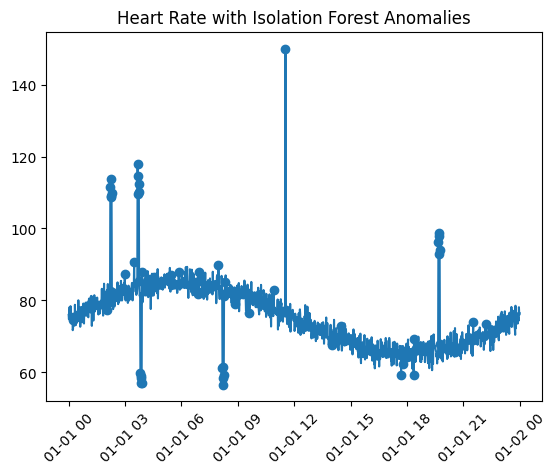

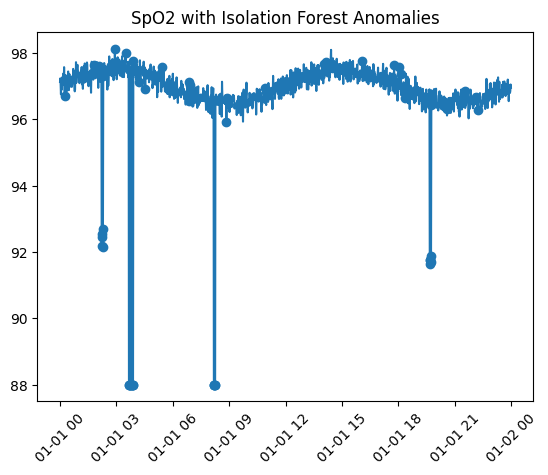

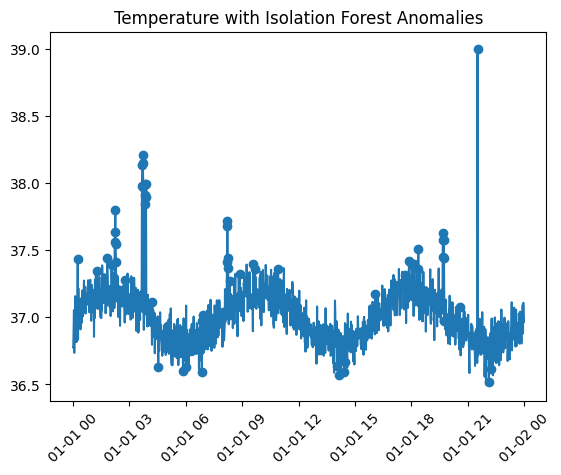

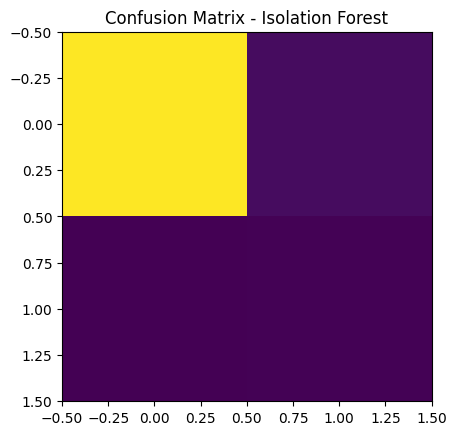

In [9]:

sample = cleaned[cleaned.patient_id == 1]

# Plot 1: Heart Rate
plt.figure()
plt.plot(sample.timestamp, sample.heart_rate)
plt.scatter(sample[sample.iso_pred==1].timestamp,
            sample[sample.iso_pred==1].heart_rate)
plt.xticks(rotation=45)
plt.title("Heart Rate with Isolation Forest Anomalies")
plt.show()

# Plot 2: SpO2
plt.figure()
plt.plot(sample.timestamp, sample.spo2)
plt.scatter(sample[sample.iso_pred==1].timestamp,
            sample[sample.iso_pred==1].spo2)
plt.xticks(rotation=45)
plt.title("SpO2 with Isolation Forest Anomalies")
plt.show()

# Plot 3: Temperature
plt.figure()
plt.plot(sample.timestamp, sample.temperature)
plt.scatter(sample[sample.iso_pred==1].timestamp,
            sample[sample.iso_pred==1].temperature)
plt.xticks(rotation=45)
plt.title("Temperature with Isolation Forest Anomalies")
plt.show()

# Plot 4: Confusion Matrix
cm = confusion_matrix(cleaned['is_anomaly'], cleaned['iso_pred'])
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Isolation Forest")
plt.show()


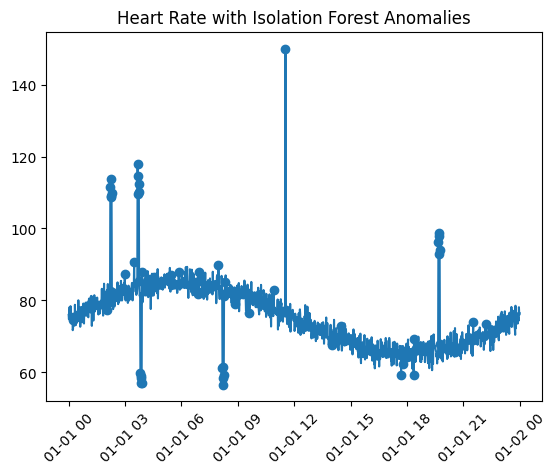

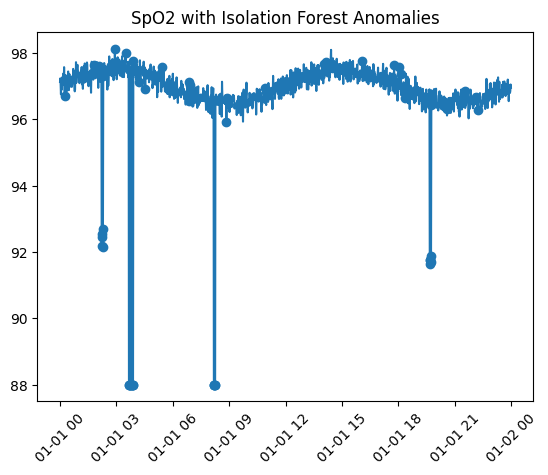

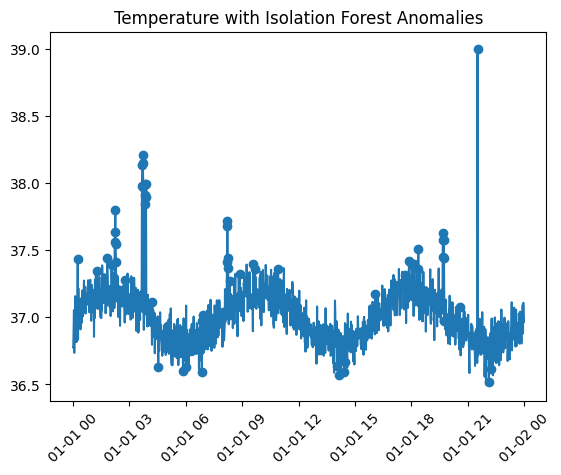

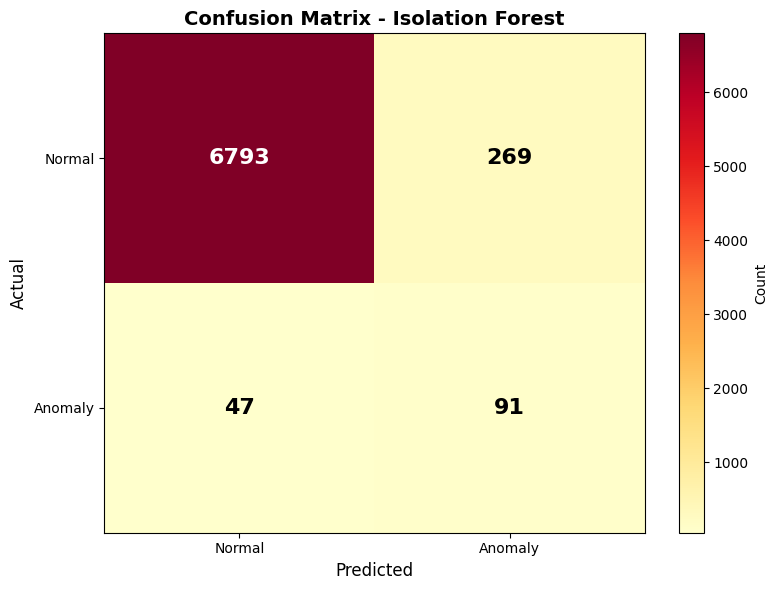


Confusion Matrix Summary:
True Negatives (TN):  6793
False Positives (FP): 269
False Negatives (FN): 47
True Positives (TP):  91


In [10]:
sample = cleaned[cleaned.patient_id == 1]

# Plot 1: Heart Rate
plt.figure()
plt.plot(sample.timestamp, sample.heart_rate)
plt.scatter(sample[sample.iso_pred==1].timestamp,
            sample[sample.iso_pred==1].heart_rate)
plt.xticks(rotation=45)
plt.title("Heart Rate with Isolation Forest Anomalies")
plt.show()

# Plot 2: SpO2
plt.figure()
plt.plot(sample.timestamp, sample.spo2)
plt.scatter(sample[sample.iso_pred==1].timestamp,
            sample[sample.iso_pred==1].spo2)
plt.xticks(rotation=45)
plt.title("SpO2 with Isolation Forest Anomalies")
plt.show()

# Plot 3: Temperature
plt.figure()
plt.plot(sample.timestamp, sample.temperature)
plt.scatter(sample[sample.iso_pred==1].timestamp,
            sample[sample.iso_pred==1].temperature)
plt.xticks(rotation=45)
plt.title("Temperature with Isolation Forest Anomalies")
plt.show()

# Plot 4: Confusion Matrix with Values
cm = confusion_matrix(cleaned['is_anomaly'], cleaned['iso_pred'])
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='YlOrRd', aspect='auto')
plt.title("Confusion Matrix - Isolation Forest", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

# Add numerical values to the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black', 
                fontsize=16, fontweight='bold')

# Set ticks and labels
plt.xticks([0, 1], ['Normal', 'Anomaly'])
plt.yticks([0, 1], ['Normal', 'Anomaly'])
plt.colorbar(label='Count')
plt.tight_layout()
plt.show()

# Print confusion matrix metrics
print("\nConfusion Matrix Summary:")
print(f"True Negatives (TN):  {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP):  {cm[1, 1]}")

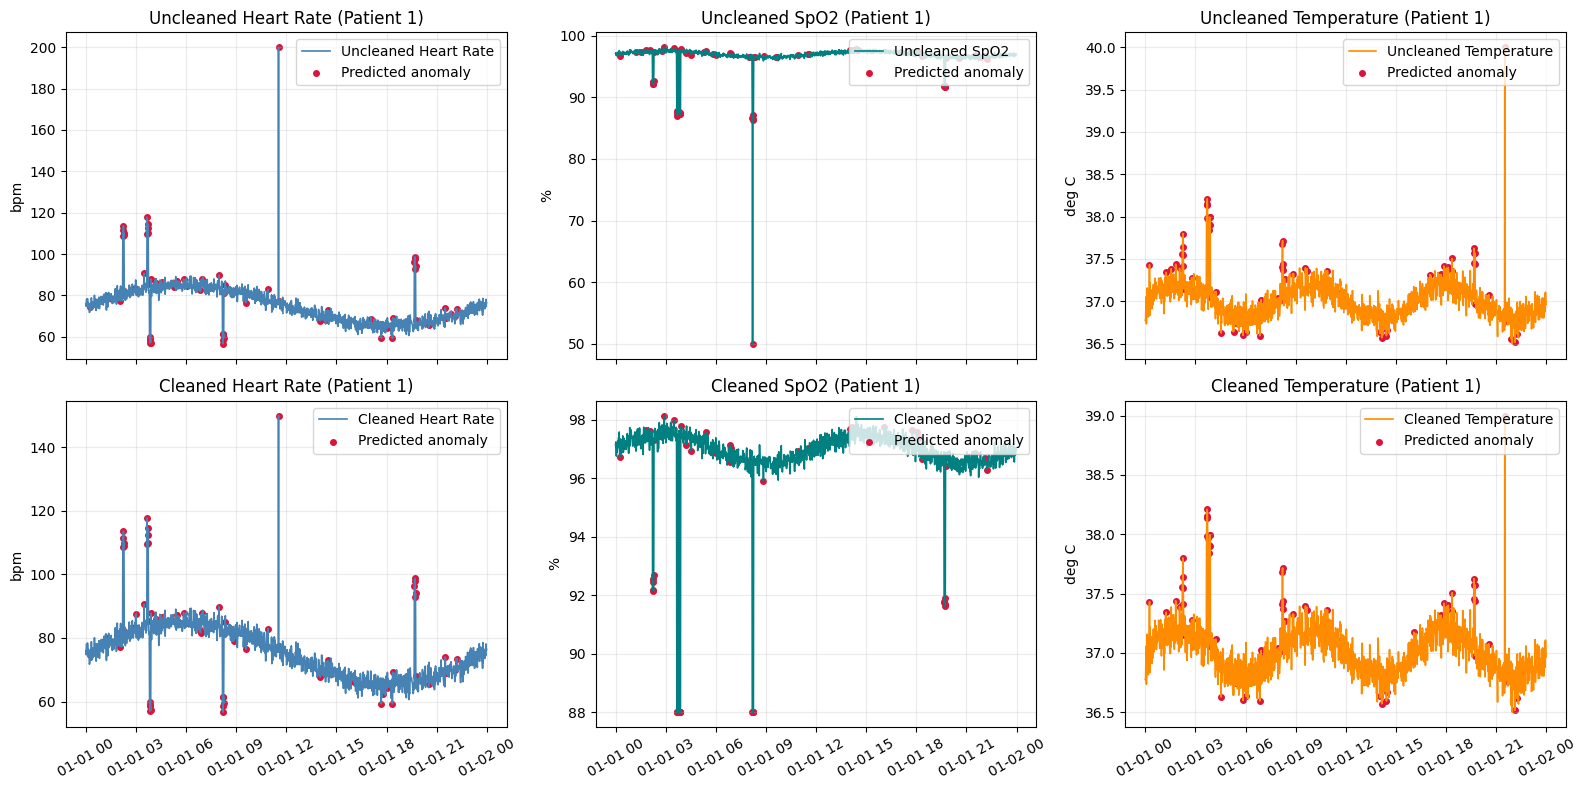

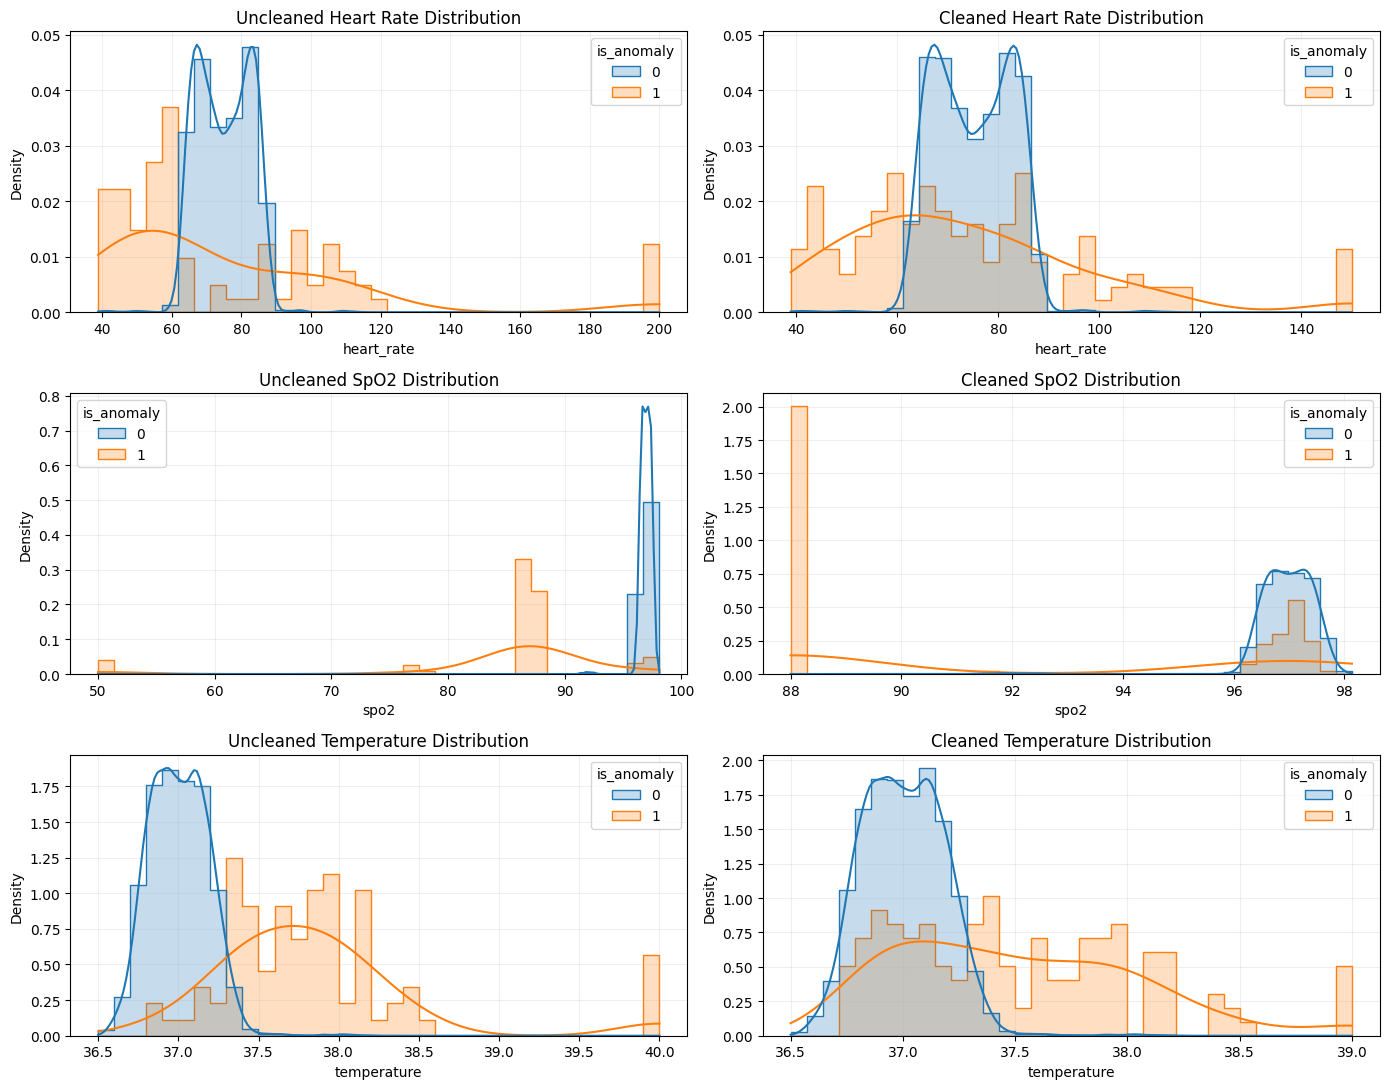

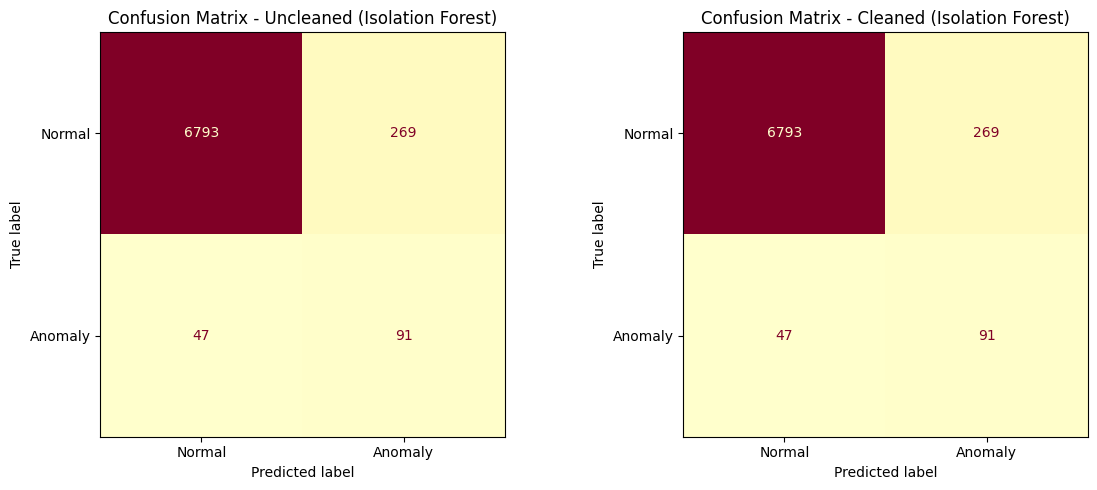

Uncleaned Confusion Matrix Summary:
TN: 6793 | FP: 269 | FN: 47 | TP: 91

Cleaned Confusion Matrix Summary:
TN: 6793 | FP: 269 | FN: 47 | TP: 91


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 0) Checks + patient selection
# -----------------------------
required_cols = {"timestamp", "patient_id", "heart_rate", "spo2", "temperature", "is_anomaly"}
if "data" not in globals():
    raise ValueError("Original dataset 'data' not found. Run Stage 1 first.")
if "cleaned" not in globals():
    raise ValueError("Cleaned dataset 'cleaned' not found. Run Stage 2 first.")
if not required_cols.issubset(data.columns):
    raise ValueError(f"'data' is missing required columns: {required_cols - set(data.columns)}")
if not required_cols.issubset(cleaned.columns):
    raise ValueError(f"'cleaned' is missing required columns: {required_cols - set(cleaned.columns)}")

selected_patient = 1  # change this to any available patient_id
if selected_patient not in set(data["patient_id"].unique()):
    raise ValueError(f"patient_id={selected_patient} not found in 'data'.")

# ---------------------------------------------
# 1) Ensure cleaned predictions exist (Stage 3)
# ---------------------------------------------
if "iso_pred" not in cleaned.columns:
    raise ValueError("Run Stage 3 model comparison cell first to generate cleaned['iso_pred'].")

# ----------------------------------------------------------
# 2) Build raw (uncleaned) predictions for fair comparison
#    (interpolate only for model input; no clipping applied)
# ----------------------------------------------------------
if "iso_pred_raw" not in data.columns:
    raw_eval = data.copy().sort_values(["patient_id", "timestamp"])

    # Fill NaNs only for model compatibility
    raw_eval[["heart_rate", "spo2", "temperature"]] = (
        raw_eval.groupby("patient_id")[["heart_rate", "spo2", "temperature"]]
        .transform(lambda x: x.interpolate().ffill().bfill())
    )

    for c in ["heart_rate", "spo2", "temperature"]:
        raw_eval[f"{c}_diff"] = raw_eval.groupby("patient_id")[c].diff().fillna(0)

    features = ["heart_rate", "spo2", "temperature", "heart_rate_diff", "spo2_diff", "temperature_diff"]

    iso_raw = IsolationForest(contamination=0.05, random_state=1)
    iso_raw.fit(raw_eval[features])
    data["iso_pred_raw"] = (iso_raw.predict(raw_eval[features]) == -1).astype(int)

# -------------------------------------------------
# 3) Trend plots for one selected patient (2 rows)
#    Row 1 = uncleaned, Row 2 = cleaned
# -------------------------------------------------
raw_sample = data[data.patient_id == selected_patient].copy().sort_values("timestamp")
clean_sample = cleaned[cleaned.patient_id == selected_patient].copy().sort_values("timestamp")

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)

signals = [
    ("heart_rate", "Heart Rate", "bpm", "steelblue"),
    ("spo2", "SpO2", "%", "teal"),
    ("temperature", "Temperature", "deg C", "darkorange"),
]

for j, (col, label, ylab, color) in enumerate(signals):
    # Uncleaned row
    axes[0, j].plot(raw_sample["timestamp"], raw_sample[col], color=color, lw=1.2, label=f"Uncleaned {label}")
    axes[0, j].scatter(
        raw_sample.loc[raw_sample["iso_pred_raw"] == 1, "timestamp"],
        raw_sample.loc[raw_sample["iso_pred_raw"] == 1, col],
        color="crimson", s=16, label="Predicted anomaly"
    )
    axes[0, j].set_title(f"Uncleaned {label} (Patient {selected_patient})")
    axes[0, j].set_ylabel(ylab)
    axes[0, j].grid(alpha=0.25)
    axes[0, j].legend(loc="upper right")

    # Cleaned row
    axes[1, j].plot(clean_sample["timestamp"], clean_sample[col], color=color, lw=1.2, label=f"Cleaned {label}")
    axes[1, j].scatter(
        clean_sample.loc[clean_sample["iso_pred"] == 1, "timestamp"],
        clean_sample.loc[clean_sample["iso_pred"] == 1, col],
        color="crimson", s=16, label="Predicted anomaly"
    )
    axes[1, j].set_title(f"Cleaned {label} (Patient {selected_patient})")
    axes[1, j].set_ylabel(ylab)
    axes[1, j].grid(alpha=0.25)
    axes[1, j].legend(loc="upper right")

for ax in axes[1, :]:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 4) Distribution comparison (uncleaned vs cleaned)
# -------------------------------------------------
fig, dist_axes = plt.subplots(3, 2, figsize=(14, 11))

for i, (col, label, _, _) in enumerate(signals):
    sns.histplot(
        data=data, x=col, hue="is_anomaly", bins=35, kde=True,
        ax=dist_axes[i, 0], element="step", stat="density", common_norm=False
    )
    dist_axes[i, 0].set_title(f"Uncleaned {label} Distribution")
    dist_axes[i, 0].grid(alpha=0.2)

    sns.histplot(
        data=cleaned, x=col, hue="is_anomaly", bins=35, kde=True,
        ax=dist_axes[i, 1], element="step", stat="density", common_norm=False
    )
    dist_axes[i, 1].set_title(f"Cleaned {label} Distribution")
    dist_axes[i, 1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 5) Side-by-side confusion matrices + summary
# -------------------------------------------------
cm_raw = confusion_matrix(data["is_anomaly"], data["iso_pred_raw"])
cm_clean = confusion_matrix(cleaned["is_anomaly"], cleaned["iso_pred"])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_raw, display_labels=["Normal", "Anomaly"]).plot(
    cmap="YlOrRd", values_format="d", ax=ax[0], colorbar=False
)
ax[0].set_title("Confusion Matrix - Uncleaned (Isolation Forest)")

ConfusionMatrixDisplay(cm_clean, display_labels=["Normal", "Anomaly"]).plot(
    cmap="YlOrRd", values_format="d", ax=ax[1], colorbar=False
)
ax[1].set_title("Confusion Matrix - Cleaned (Isolation Forest)")

plt.tight_layout()
plt.show()

print("Uncleaned Confusion Matrix Summary:")
print(f"TN: {cm_raw[0,0]} | FP: {cm_raw[0,1]} | FN: {cm_raw[1,0]} | TP: {cm_raw[1,1]}")
print("\nCleaned Confusion Matrix Summary:")
print(f"TN: {cm_clean[0,0]} | FP: {cm_clean[0,1]} | FN: {cm_clean[1,0]} | TP: {cm_clean[1,1]}")

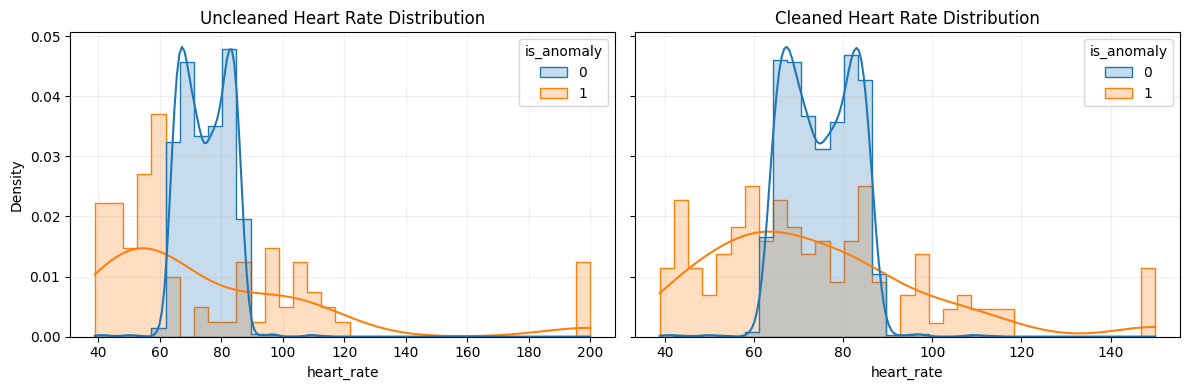

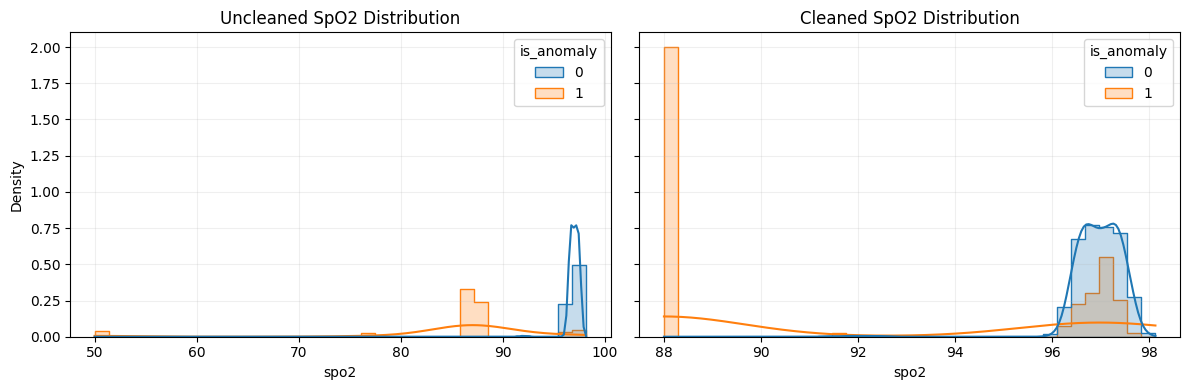

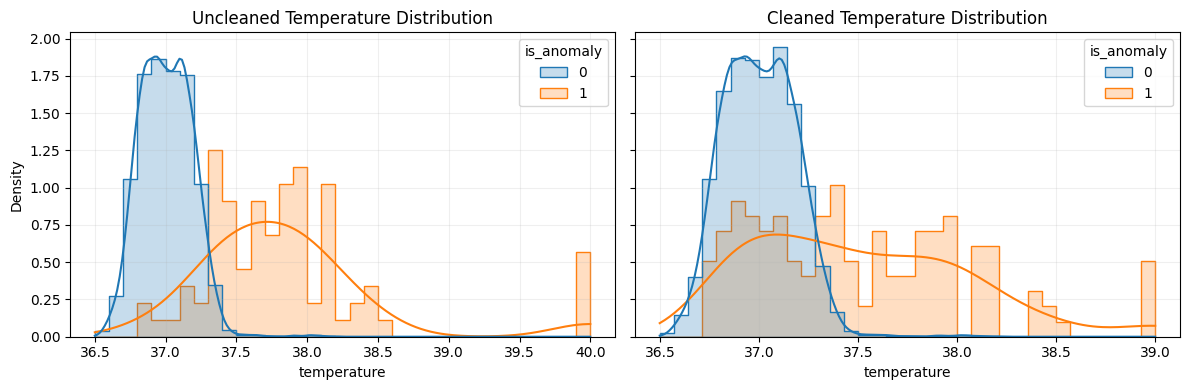

In [13]:
# Separate distribution images (one figure per signal)
signals = [
    ("heart_rate", "Heart Rate"),
    ("spo2", "SpO2"),
    ("temperature", "Temperature"),
]

for col, label in signals:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    sns.histplot(
        data=data, x=col, hue="is_anomaly",
        bins=35, kde=True, stat="density", common_norm=False,
        element="step", ax=ax[0]
    )
    ax[0].set_title(f"Uncleaned {label} Distribution")
    ax[0].grid(alpha=0.2)

    sns.histplot(
        data=cleaned, x=col, hue="is_anomaly",
        bins=35, kde=True, stat="density", common_norm=False,
        element="step", ax=ax[1]
    )
    ax[1].set_title(f"Cleaned {label} Distribution")
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Optional: save each figure as separate image file
    # fig.savefig(f"{col}_distribution_comparison.png", dpi=300, bbox_inches="tight")


## Conclusion

1. Isolation Forest performs well for multivariate anomaly detection.
2. One-Class SVM may overfit if dataset is noisy.
3. Recall is critical in healthcare to avoid missing medical emergencies.
4. Precision is important to reduce false alarms in telemedicine.
5. Isolation Forest is computationally efficient → suitable for low-cost IoT edge devices in Nepal.
6. The system supports scalable remote monitoring in rural health posts.


### Isolation Forest is more suitable for AIoT healthcare deployment in resource-constrained Nepali environments.


## References

LoRaWAN Architecture | The Things Network
https://www.thethingsnetwork.org/docs/lorawan/architecture/

ESurf - Development of smart boulders to monitor mass movements via the Internet of Things: a pilot study in Nepal
https://esurf.copernicus.org/articles/9/295/2021/

10 IoT Design Considerations: Interoperability & Security – Grid Connect
https://www.gridconnect.com/blogs/news/10-internet-of-things-iot-design-considerations-interoperability-and-security

ScalableDigitalHealth (SDH): An IoT-Based Scalable Framework for Remote Patient Monitoring - PMC 
https://pmc.ncbi.nlm.nih.gov/articles/PMC10893503/

Wearable Health Devices—Vital Sign Monitoring, Systems and Technologies - PMC 
https://pmc.ncbi.nlm.nih.gov/articles/PMC6111409/

Synthetic Data Generation in Python: A Hands-On Guide | DataCamp
https://www.datacamp.com/tutorial/synthetic-data-generation

Pulse Oximeter Readings Explained: SpO2 & Heart Rate | Gwinnett Pulmonary
https://gwinnettlung.com/decoding-pulse-oximetry-readings-what-each-number-means/

What a Normal Body Temperature Is
https://health.clevelandclinic.org/body-temperature-what-is-and-isnt-normal

Working with missing data — pandas 3.0.1 documentation
https://pandas.pydata.org/docs/user_guide/missing_data.html

Handling outliers with Pandas - GeeksforGeeks
https://www.geeksforgeeks.org/pandas/handling-outliers-with-pandas/

Anomaly detection using Isolation Forest - GeeksforGeeks
https://www.geeksforgeeks.org/machine-learning/anomaly-detection-using-isolation-forest/
